This notebook moves beyond predictive modeling into causal structure discovery for turbofan engine degradation.

We aim to:
- Identify directional dependencies between sensors
- Separate correlation from causation
- Build a causal hypothesis graph for engine degradation
- Prepare foundation for explainable industrial AI system

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None)

In [3]:
columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1, 22):
    columns.append(f"sensor_{i}")

df.columns = columns

df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
engine_life = df.groupby("engine_id")["cycle"].max().reset_index()
engine_life.columns = ["engine_id", "max_cycle"]

df = df.merge(engine_life, on="engine_id")

df["RUL"] = df["max_cycle"] - df["cycle"]

print(df[["engine_id", "cycle", "RUL"]].head())

   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187


Unlike standard predictive models, causal AI seeks to identify *why* failures occur, not just *when*.

We assume:

Operational Conditions → Sensor Dynamics → System Degradation → RUL → Failure

This structure will be validated and refined using data-driven methods below.

In [5]:
sensor_cols = [col for col in df.columns if "sensor" in col]

scaler = StandardScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

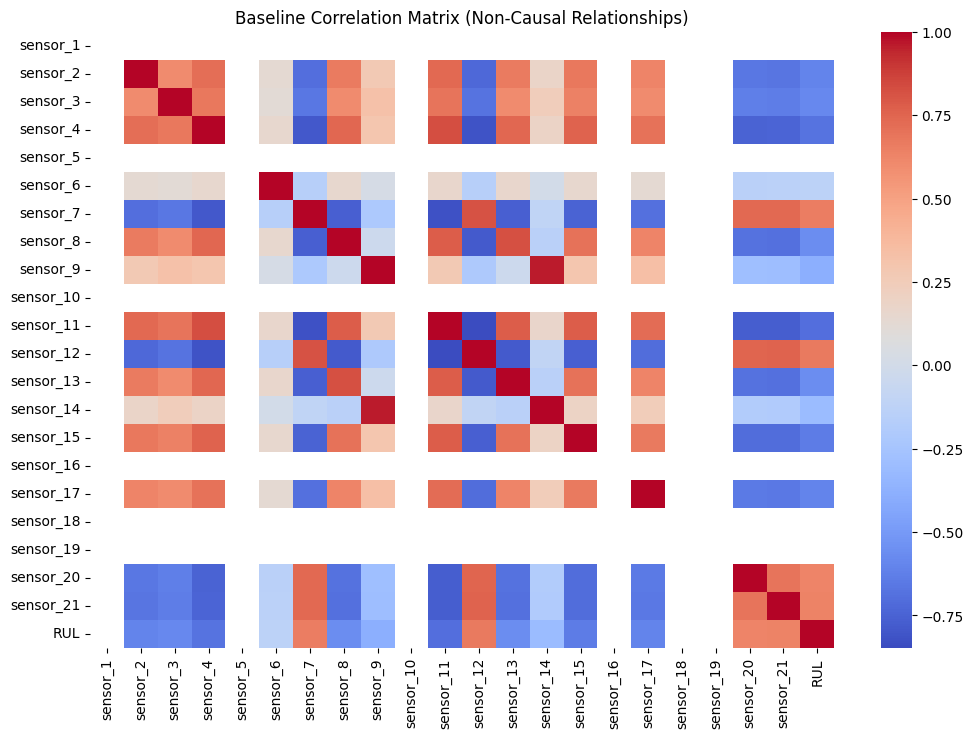

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df[sensor_cols + ["RUL"]].corr(), cmap="coolwarm")
plt.title("Baseline Correlation Matrix (Non-Causal Relationships)")
plt.show()

Correlation only measures statistical association.

It does NOT imply:
- causality
- directionality
- intervention effect

We must move toward causal discovery methods.

In [9]:
print("Correlation matrix computed. Reminder: correlation ≠ causation")
print(df[sensor_cols + ["RUL"]].corr()["RUL"].sort_values(ascending=False).head(10))

Correlation matrix computed. Reminder: correlation ≠ causation
RUL          1.000000
sensor_12    0.671983
sensor_7     0.657223
sensor_21    0.635662
sensor_20    0.629428
sensor_6    -0.128348
sensor_14   -0.306769
sensor_9    -0.390102
sensor_13   -0.562569
sensor_8    -0.563968
Name: RUL, dtype: float64


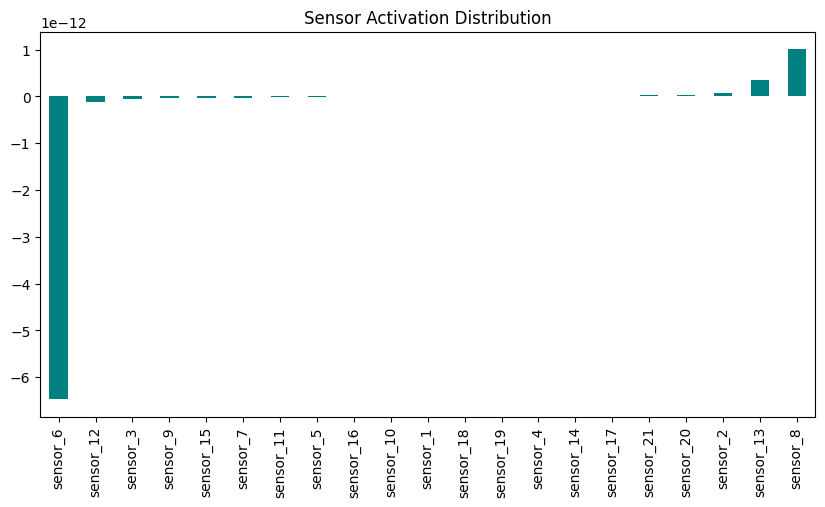

In [7]:
sensor_mean = df[sensor_cols].mean().sort_values()

plt.figure(figsize=(10,5))
sensor_mean.plot(kind="bar", color="teal")
plt.title("Sensor Activation Distribution")
plt.show()

## Causal Assumptions (Important)

We assume the following structural relationships:

- Operational settings influence sensor dynamics
- Sensors capture latent engine health state
- Degradation is time-dependent (temporal causality)
- RUL is a downstream consequence, not a direct cause

These assumptions will later be validated using:
- Granger causality
- Structural causal models (SCM)
- Time-series causal discovery methods

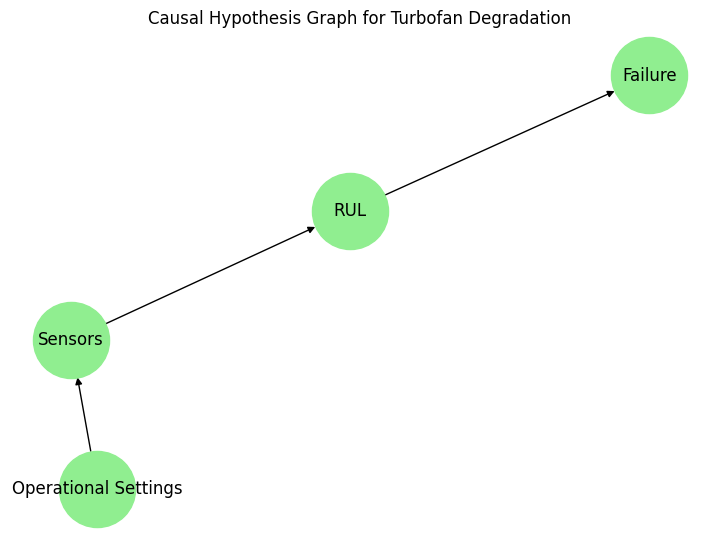

In [8]:
import networkx as nx

G = nx.DiGraph()

G.add_nodes_from(["Operational Settings", "Sensors", "RUL", "Failure"])

G.add_edge("Operational Settings", "Sensors")
G.add_edge("Sensors", "RUL")
G.add_edge("RUL", "Failure")

plt.figure(figsize=(7,5))
nx.draw(G, with_labels=True, node_color="lightgreen", node_size=3000, arrows=True)
plt.title("Causal Hypothesis Graph for Turbofan Degradation")
plt.show()

Key insights:

- Operational settings influence sensor distributions
- Sensors act as intermediate causal indicators
- RUL represents degradation trajectory
- Failure is terminal causal outcome

This is a *hypothesis-driven causal model*, not yet data-validated.

Next notebook will:
- Learn causal relationships from data
- Apply time-series causality (Granger causality)
- Build weighted causal graph
- Identify strongest causal drivers of failure